In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/dow_jones_index.data')
# make sure date is datetime
df["date"] = pd.to_datetime(df["date"])

# use weekly return
pcp_weekly = df.pivot(index="date", columns="stock", values="percent_change_price")

pcp_weekly = pcp_weekly.sort_index()
pcp_weekly.head()

stock,AA,AXP,BA,BAC,CAT,CSCO,CVX,DD,DIS,GE,...,MRK,MSFT,PFE,PG,T,TRV,UTX,VZ,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,,
2011-01-07,3.79267,2.448040,4.88284,2.88809,-0.688705,2.542790,-0.512765,-0.579421,4.531000,-0.32450,...,2.920910,1.960780,3.615820,0.170834,-2.796500,-4.920660,-0.138906,-0.36051,-0.276600,2.536630
2011-01-14,-4.42849,4.638010,0.93633,7.62174,0.858277,1.289400,2.067070,3.105590,0.717765,1.12843,...,-8.132040,0.354610,0.658617,1.754660,-0.385424,2.842620,1.034880,-2.98222,2.162160,3.607080
2011-01-21,-2.47066,-0.065175,1.15721,-5.50398,-1.497450,-2.356270,0.903809,-2.382390,1.714870,4.00421,...,-0.498973,-0.497159,0.054496,0.396040,-0.770578,0.695716,1.160440,-1.21538,1.125020,1.529760
2011-01-28,1.63831,-4.755700,-3.20190,-4.56140,3.203540,0.431862,-0.553840,3.819160,-1.992940,1.35474,...,-2.706680,-0.963597,-0.981997,-2.579670,-3.408290,1.215090,1.457760,2.15023,2.365050,0.177552
2011-02-04,5.93325,-0.702470,3.06093,4.23049,3.599290,5.351170,3.473630,4.745760,4.277660,2.13612,...,-1.201560,0.000000,6.102250,-1.149960,2.005840,2.866870,0.880196,1.87991,-0.744021,4.204200


# Creating the Lagged Windows

In [3]:
stocks = pcp_weekly.columns.tolist()

#Function
def create_window(weekly_data, window, stock_list = stocks):
  #weekly_data contains each stock's pcp for desired weeks, length x+1
  #window determines how far to look back, looks at prev x weeks (hence why we need x+1 data)

  lead_data = weekly_data.copy().iloc[:(window), :].reset_index(drop=True)
  lag_data = weekly_data.copy().iloc[1:(window+1), :].reset_index(drop=True)
  new_data_dict = {}

  for stock in stock_list:
    stock_lead = lead_data[stock]
    #Do we want to do self-leading stocks? Seeing if pcp correlated with pcp of same stock for next week?
    new_data_dict[stock] = lag_data.corrwith(stock_lead)
    #print(lag_data.corrwith(stock_lead))

  lag_corrs = pd.DataFrame(new_data_dict)
  #lag_corrs.index = [stock + '_lag' for stock in stocks]
  #lag_corrs.columns = [stock + '_lead' for stock in stocks] #don't need this
  return lag_corrs

In [4]:
#Testing
weekly_test = pcp_weekly.copy().iloc[:6]
create_window(weekly_test, window = 5) #it works now

,AA,AXP,BA,BAC,CAT,CSCO,CVX,DD,DIS,GE,...,MRK,MSFT,PFE,PG,T,TRV,UTX,VZ,WMT,XOM
stock,,,,,,,,,,,,,,,,,,,,,
AA,0.005561,-0.905183,-0.865413,-0.740724,0.478172,-0.351180,-0.174735,0.269603,-0.733066,0.484927,...,-0.128407,-0.911770,-0.510648,-0.752999,-0.196183,0.456411,0.828644,0.589523,0.480792,-0.691525
AXP,0.801477,0.135711,0.584283,0.629420,0.457531,0.968420,0.317558,0.483954,0.651658,-0.606835,...,0.295991,0.562675,0.881408,-0.176137,0.306254,-0.209541,-0.599485,0.399251,-0.730671,0.615035
BA,0.370044,-0.255518,-0.319212,0.316425,0.732713,0.530781,-0.150847,0.779704,-0.311215,-0.717601,...,-0.239759,0.037493,0.054807,-0.481838,-0.297962,0.048708,0.017798,0.447542,0.187113,-0.049280
BAC,0.811703,-0.363252,0.203009,-0.076471,0.251807,0.457787,-0.496112,0.112342,0.251977,-0.651591,...,0.685819,0.418337,0.360426,-0.594513,-0.466748,-0.662842,-0.542745,0.657545,-0.434611,-0.214865
CAT,0.559316,-0.859969,-0.244153,-0.677451,0.379553,0.025040,0.010866,0.072526,-0.028593,0.504905,...,0.484402,-0.546255,0.137260,-0.801556,0.108413,0.133714,0.336228,0.827503,-0.281243,-0.368491
CSCO,-0.432359,-0.169999,-0.472446,-0.530741,-0.419266,-0.730779,-0.916312,-0.444747,-0.607287,-0.184761,...,0.048190,-0.052177,-0.824504,-0.054184,-0.935245,-0.440325,0.078960,-0.184122,0.654237,-0.833623
CVX,0.042872,-0.320047,-0.472836,-0.199166,0.165326,-0.129545,-0.798921,0.151850,-0.553647,-0.640336,...,0.009503,0.054421,-0.479234,-0.405934,-0.890422,-0.385139,-0.024799,0.232375,0.486434,-0.637897
DD,0.635765,-0.817111,-0.123240,-0.740279,0.172158,-0.033677,-0.343054,-0.147767,0.042819,0.242965,...,0.744921,-0.271021,0.100955,-0.799669,-0.223755,-0.273556,0.042662,0.811124,-0.332586,-0.529934
DIS,0.629854,-0.402804,-0.166653,0.313876,0.968487,0.783173,0.414350,0.931640,-0.018682,-0.256652,...,-0.167136,-0.208224,0.463013,-0.605726,0.324203,0.421751,0.185723,0.696200,-0.202007,0.278033


In [5]:
#Testing stuff
aa_p1 = pcp_weekly.copy().iloc[:5]['AA'].to_numpy()
aa_p2 = pcp_weekly.copy().iloc[1:6]['AA'].to_numpy()
print(aa_p1)
print(aa_p2)
np.corrcoef(aa_p1, aa_p2)

[ 3.79267 -4.42849 -2.47066  1.63831  5.93325]
[-4.42849  -2.47066   1.63831   5.93325   0.230814]


array([[1.        , 0.00556084],
       [0.00556084, 1.        ]])

In [6]:
#Network Setup Function

def window_network(window_data, cor_min = 0.3):
  for col in window_data.columns:
    for row in window_data.index:
      if np.abs(window_data.loc[row, col]) < cor_min:
        window_data.loc[row, col] = 0
  window_g = nx.from_pandas_adjacency(window_data, create_using = nx.DiGraph)
  return window_g

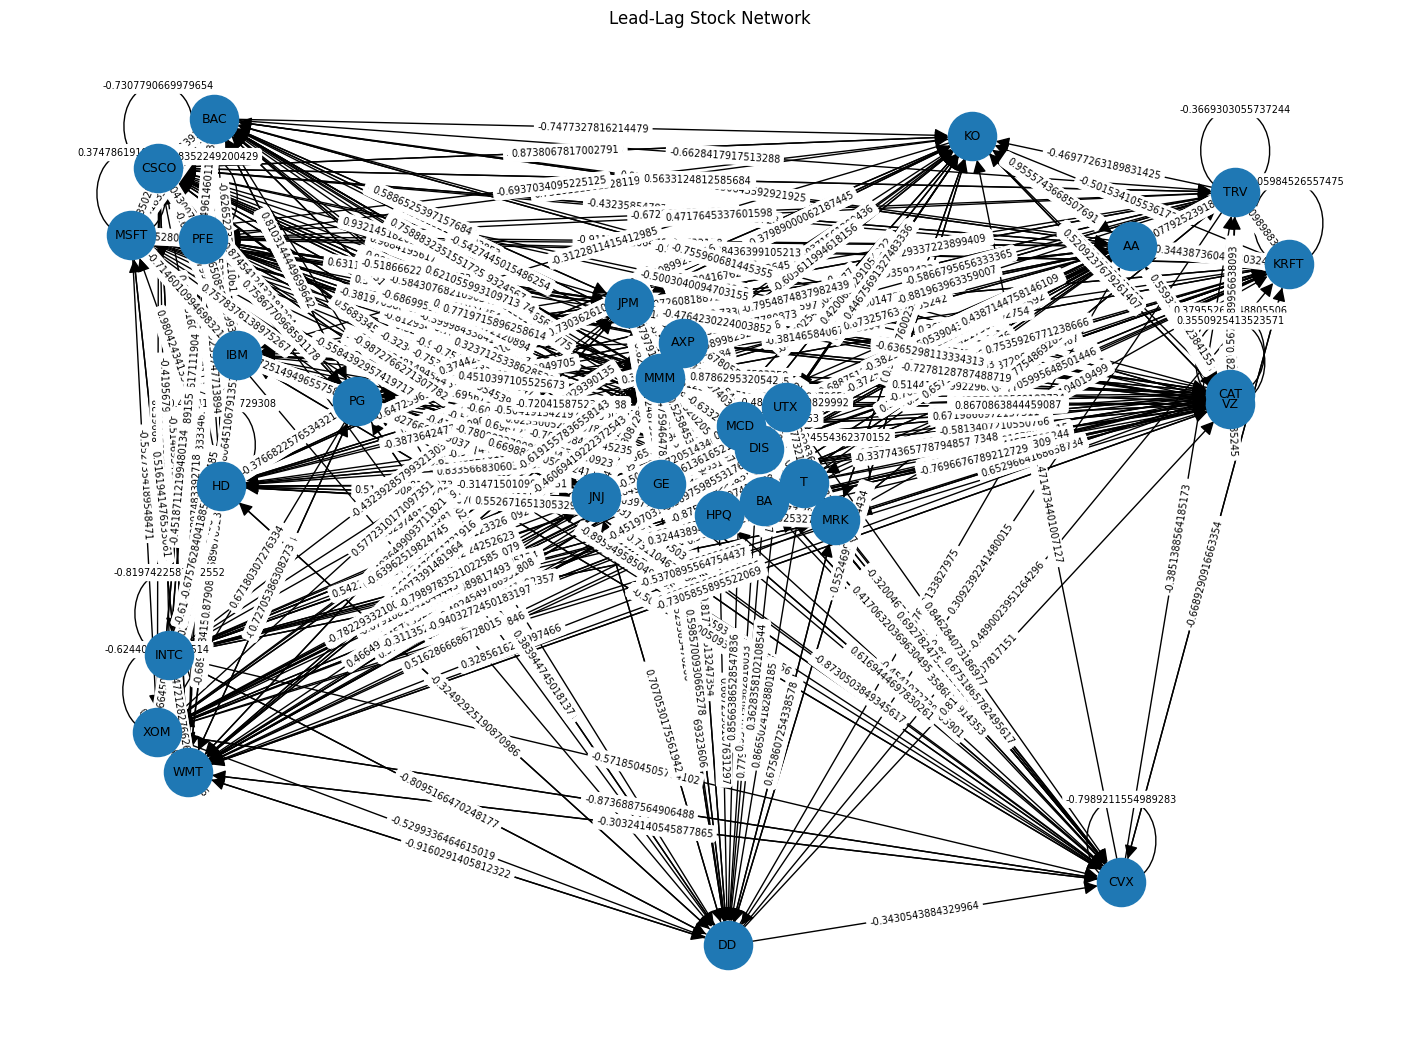

In [7]:
#Testing
test_window = create_window(weekly_test, window = 5)
test_g = window_network(test_window)
test_g.edges(data=True)
plt.figure(figsize=(14, 10))

pos = nx.spring_layout(test_g, seed=42)

nx.draw(
    test_g,
    pos,
    with_labels=True,
    node_size=1200,
    font_size=9,
    arrows=True,
    arrowsize=20
)

edge_labels = nx.get_edge_attributes(test_g, 'weight')

nx.draw_networkx_edge_labels(
    test_g,
    pos,
    edge_labels=edge_labels,
    font_size=7
)

plt.title("Lead-Lag Stock Network")
plt.show()

# Sim Setup

In [8]:
#Function for investment for next week
def invest(window_data, prev_investments, last_week_open, last_week_close, money = 0, min_to_invest = 0.5):
  #window_data: correlation data for specified window up until current week, dataframe of 30x30
  #prev_investments: a Series with shares invested in each stock, i.e. 'AA': 3, ..., 30x1
  #last_week_open: a Series with opening prices for each share for each stock, i.e. 'AA': 15.82, ..., 30x1
  #last_week_close: same thing but with closing prices, 30x1
  #min_to_invest: minimum correlation (abs value) to either invest/deinvest from a stock
    #So, have a stock, say AA, then see correlations of stocks 'leading' it: if neg correlation < -min and stock decreased
    #in price from last week, then would want to invest in AA, and would want to deinvest otw
    #If pos corr > min, would invest if price incr during past week, deinvest if decreased


  money = money

  price_change = last_week_close - last_week_open

  #First determine which/how many shares to sell to determine how much money we have to invest
  share_sell = {}
  #Going to initialize them all lol
  for stock in window_data.columns:
    share_sell[stock] = 0

  for stock in window_data.columns:
    lag_corrs = window_data.loc[stock] #To get row corresponding to stock
    for stock_lead in window_data.columns:
      #Now iterate over these to determine whether or not to invest
      stock_pc = price_change[stock_lead]
      stock_cor = lag_corrs[stock_lead]
      if np.abs(stock_cor) > min_to_invest:
        if stock_cor < 0:
          if stock_pc < 0:
            share_sell[stock] += -1
          else:
            share_sell[stock] += 1 #To cancel out, since you now SHOULD invest
        else:
          if stock_cor > 0:
            if stock_pc < 0:
              share_sell[stock] += 1
            else:
              share_sell[stock] += -1 #Ok now should be good?
      else:
        share_sell[stock] += 0

  new_investments = {}
  for stock in window_data.columns:
    new_investments[stock] = prev_investments[stock]
  #Now see how much money you have
  for stock in window_data.columns:
    if share_sell[stock] > 0:
      if share_sell[stock] > prev_investments[stock]:
        money += prev_investments[stock] * last_week_open[stock]
        new_investments[stock] = 0
      else:
        money += share_sell[stock] * last_week_open[stock]
        new_investments[stock] = prev_investments[stock] - share_sell[stock]

  #Now to invest in new things!
  #Going to do it such that it is determined by strength of correlation
  #Can use same share_sell list from earlier I think?
  stocks_to_invest = [stock for stock in share_sell.keys() if share_sell[stock] < 0]
  #Actually going to do a simpler mechanism for investing here, will be uniform based on money left
    #Can make more complex later if desired
  if len(stocks_to_invest) == 0:
    return new_investments, money
  money_per_stock = money / len(stocks_to_invest)
  for stock in stocks_to_invest:
    shares_to_buy = np.trunc(money_per_stock / last_week_close[stock])
    new_investments[stock] += shares_to_buy
    money -= shares_to_buy * last_week_close[stock]

  #Ok so now have leftover money
  #Perhaps invest in most expensive stock to invest in if possible, if not then next one, etc.
  #Actually doing it randomly until I can't
  stocks_to_invest_close = [last_week_close[stock] for stock in stocks_to_invest]
  if len(stocks_to_invest) > 0:
    while(money > min(stocks_to_invest_close)):
      stock = np.random.choice(stocks_to_invest)
      shares_to_buy = np.trunc(money / last_week_close[stock])
      new_investments[stock] += shares_to_buy
      money -= shares_to_buy * last_week_close[stock]

  return new_investments, money

In [9]:
#Oh okay need to make the open/close data here

close = df.pivot(index="date", columns="stock", values="close")
close = close.sort_index()
close_float = close.map(lambda x: float(x[1:]))
open = df.pivot(index = "date", columns = "stock", values = "open")
open = open.sort_index()
open_float = open.map(lambda x: float(x[1:]))
print(close_float.head())
print(open_float.head()) #Ok perfect

stock          AA    AXP     BA    BAC    CAT   CSCO    CVX     DD    DIS  \
date                                                                        
2011-01-07  16.42  44.36  69.38  14.25  93.73  20.97  91.19  49.76  39.45   
2011-01-14  15.97  46.25  70.07  15.25  94.01  21.21  92.83  49.80  39.29   
2011-01-21  15.79  46.00  71.68  14.25  92.75  20.72  93.78  48.35  39.74   
2011-01-28  16.13  43.86  69.23  13.60  95.68  20.93  93.37  50.29  38.85   
2011-02-04  17.14  43.82  71.38  14.29  99.59  22.05  97.11  52.53  40.71   

stock          GE  ...    MRK   MSFT    PFE     PG      T    TRV    UTX  \
date               ...                                                    
2011-01-07  18.43  ...  37.35  28.60  18.34  64.50  28.85  53.33  79.08   
2011-01-14  18.82  ...  34.23  28.30  18.34  65.53  28.43  54.63  79.08   
2011-01-21  19.74  ...  33.90  28.02  18.36  65.91  28.33  55.00  80.20   
2011-01-28  20.20  ...  33.07  27.75  18.15  64.20  27.49  55.81  81.43   
2011-02-04

In [12]:
#Ok now to test
weekly_test = pcp_weekly.copy().iloc[:4]
test_window = create_window(weekly_test, window = 3)
print(test_window)

#Test prev_investments
test_prev = {}
for stock in test_window.columns:
  test_prev[stock] = 10
test_prev_df = pd.Series(test_prev)
print(test_prev_df)

prev_open = open_float.copy().iloc[4]
prev_close = close_float.copy().iloc[4]
print(prev_open)
print(prev_close)

             AA       AXP        BA       BAC       CAT      CSCO       CVX  \
stock                                                                         
AA    -0.577202 -0.692669 -0.714178 -0.773963 -0.519726 -0.997346  0.369344   
AXP    0.729781  0.533286  0.840471  0.630636  0.337093  0.962269 -0.548865   
BA     0.246078  0.905200  0.415763  0.949533  0.791462  0.957152 -0.011636   
BAC    0.986327 -0.024755  0.999894  0.094991 -0.241015  0.650304 -0.920064   
CAT    0.229204 -0.999162  0.051087 -0.987094 -0.984251 -0.715339 -0.451330   
CSCO   0.830752 -0.703744  0.717570 -0.613718 -0.841096 -0.047894 -0.938221   
CVX    0.683439  0.587542  0.803180  0.680108  0.398026  0.978023 -0.492943   
DD     0.603780 -0.896974  0.451177 -0.837660 -0.971512 -0.371046 -0.774060   
DIS    0.030773  0.975658  0.209368  0.994884  0.904860  0.871938  0.204758   
GE    -0.734139  0.805615 -0.600597  0.728973  0.914943  0.202560  0.873036   
HD     0.916649  0.219076  0.973431  0.334203  0.002

In [13]:
#Now to debug the function
print(invest(test_window, test_prev_df, prev_open, prev_close, money = 0, min_to_invest = 0.5))
#Ooh ok it does stuff!!!

({'AA': np.int64(8), 'AXP': np.int64(8), 'BA': np.float64(15.0), 'BAC': np.int64(8), 'CAT': np.int64(7), 'CSCO': np.int64(5), 'CVX': np.int64(10), 'DD': np.int64(4), 'DIS': np.float64(14.0), 'GE': np.float64(18.0), 'HD': np.int64(7), 'HPQ': np.float64(13.0), 'IBM': np.float64(11.0), 'INTC': np.int64(4), 'JNJ': np.float64(12.0), 'JPM': np.int64(9), 'KO': np.int64(8), 'KRFT': np.int64(9), 'MCD': np.float64(12.0), 'MMM': np.float64(11.0), 'MRK': np.float64(17.0), 'MSFT': np.int64(8), 'PFE': np.int64(9), 'PG': np.float64(12.0), 'T': np.float64(15.0), 'TRV': np.int64(8), 'UTX': np.int64(8), 'VZ': np.float64(14.0), 'WMT': np.int64(5), 'XOM': np.int64(9)}, np.float64(2.2500000000004263))


In [14]:
#Now for a function to select the right data inputs
#Wait actually just going to do week # instead of the datetime value lol
def get_data(week, window_size):
  window_data = create_window(pcp_weekly.copy().iloc[(week-window_size):week, ].reset_index(drop = True),
                              window = window_size)
  open_series = open_float.copy().iloc[week]
  close_series = close_float.copy().iloc[week]
  return window_data, open_series, close_series

In [15]:
#Going to do a test run through all weeks for one window size
init_invest = {}
for stock in pcp_weekly.columns:
  init_invest[stock] = 10 #Doing by shares first, will figure out by money later lol

window_size = 15
init_data, init_open, init_close = get_data(window_size + 1, window_size)

investment, money_left = invest(init_data, init_invest, init_open, init_close, money = 0, min_to_invest = 0.5)
i = window_size + 2
while(i < len(pcp_weekly)):
  data, open_series, close_series = get_data(i, window_size)
  investment, money_left = invest(data, investment, open_series, close_series, money = money_left, min_to_invest = 0.5)
  i += 1
print(investment)
print(money_left)

{'AA': np.float64(16.0), 'AXP': np.float64(9.0), 'BA': np.float64(9.0), 'BAC': np.float64(11.0), 'CAT': np.float64(9.0), 'CSCO': np.float64(14.0), 'CVX': np.float64(8.0), 'DD': np.float64(7.0), 'DIS': np.float64(15.0), 'GE': np.float64(11.0), 'HD': np.float64(11.0), 'HPQ': 10, 'IBM': np.float64(8.0), 'INTC': np.float64(13.0), 'JNJ': np.float64(19.0), 'JPM': np.float64(5.0), 'KO': np.float64(8.0), 'KRFT': np.float64(18.0), 'MCD': np.float64(7.0), 'MMM': np.float64(10.0), 'MRK': np.float64(1.0), 'MSFT': np.float64(11.0), 'PFE': np.float64(17.0), 'PG': np.float64(0.0), 'T': np.float64(29.0), 'TRV': np.float64(9.0), 'UTX': np.float64(14.0), 'VZ': np.float64(7.0), 'WMT': np.float64(11.0), 'XOM': np.float64(12.0)}
16.849999999999994


In [16]:
#Now to see how much this is compared to initial
init_money = 0
final_money_constant = 0
final_money = 0
final_money += money_left
for stock in pcp_weekly.columns:
  init_money += init_invest[stock] * close_float.iloc[window_size][stock]
  final_money_constant += init_invest[stock] * close_float.iloc[i-1][stock]
  final_money += investment[stock] * close_float.iloc[i-1][stock]
print(init_money)
print(final_money_constant)
print(final_money)

16523.899999999998
15769.199999999997
15825.28


It's being weird, or this correlation method is just not good at predicting stuff lol.

# Simulation

In [17]:
#Start with list of window lengths
window_lengths = list(range(3, 16, 2))#[7, 10] #4, 5, 6, , 15

#And we'll start at first possible week for all windows
init_week = max(window_lengths) + 1
init_invest = {}
for stock in pcp_weekly.columns:
  init_invest[stock] = 10

money_dict = {}
for window_size in window_lengths:
  money = 0
  for stock in pcp_weekly.columns:
    money += init_invest[stock] * close_float.iloc[init_week][stock]
  money_dict[f"window_{window_size}"] = []
  money_dict[f"window_{window_size}"].append(money)
money_const = 0
for stock in pcp_weekly.columns:
  money_const += init_invest[stock] * close_float.iloc[init_week][stock]
money_dict["constant"] = []
money_dict["constant"].append(money_const)

#oops
investment, money_left = invest(init_data, init_invest, init_open, init_close, money = 0, min_to_invest = 0.5)

for i in range(init_week, len(pcp_weekly)):
  for window_size in window_lengths: #Wait I did this wrong
    window_data, i_open, i_close = get_data(i, window_size)
    investment, money_left = invest(window_data, investment, i_open, i_close, money = money_left, min_to_invest = 0.5)
    money_rep = 0
    money_rep += money_left
    for stock in pcp_weekly.columns:
      money_rep += investment[stock] * close_float.iloc[i][stock]
    money_dict[f"window_{window_size}"].append(money_rep)
  money_const = 0
  for stock in pcp_weekly.columns:
    money_const += init_invest[stock] * close_float.iloc[i][stock]
  money_dict["constant"].append(money_const)

print(money_dict)

{'window_3': [np.float64(16924.8), np.float64(16914.069999999996), np.float64(16606.269999999997), np.float64(16540.57), np.float64(16361.83), np.float64(16250.800000000003), np.float64(15834.079999999998), np.float64(15670.23), np.float64(15748.16), np.float64(15675.899999999998)], 'window_5': [np.float64(16924.8), np.float64(16830.57), np.float64(16618.680000000004), np.float64(16533.99), np.float64(16363.770000000002), np.float64(16248.740000000002), np.float64(15868.23), np.float64(15671.95), np.float64(15748.42), np.float64(15681.259999999998)], 'window_7': [np.float64(16924.8), np.float64(16772.829999999998), np.float64(16623.760000000002), np.float64(16534.09), np.float64(16364.7), np.float64(16223.65), np.float64(15910.33), np.float64(15678.149999999998), np.float64(15747.14), np.float64(15682.83)], 'window_9': [np.float64(16924.8), np.float64(16765.6), np.float64(16631.73), np.float64(16535.39), np.float64(16366.150000000001), np.float64(16203.820000000003), np.float64(15934.7

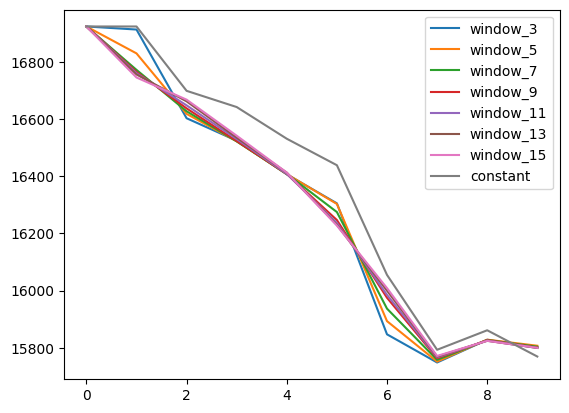

In [ ]:
#Now to plot
money_df = pd.DataFrame(money_dict)
#test_money_df = money_df.map(lambda x: np.log(x))
money_df.plot(kind = "line")
plt.show()

# New Sim Setup

Beginning Walk-Forward Window Size Simulation...

Week   | Date         | Window 3w       | Window 4w       | Window 5w       | Window 6w       | Window 7w       | Window 8w       | Window 9w       | Window 10w      | All 30         
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 unconverted_output=Week 11     | 2011-03-18   | $100.00         | $100.00         | $100.00         | $100.00         | $100.00         | $100.00         | $100.00         | $100.00         | $100.00        
 unconverted_output=Week 12     | 2011-03-25   | $100.36         | $91.16          | $99.81          | $99.61          | $97.47          | $101.26         | $102.52         | $102.52         | $101.50        
 unconverted_output=Week 13     | 2011-04-01   | $101.99         | $90.98          | $100.69         | $100.17         | $96.87          | $102.45         | $103.43     

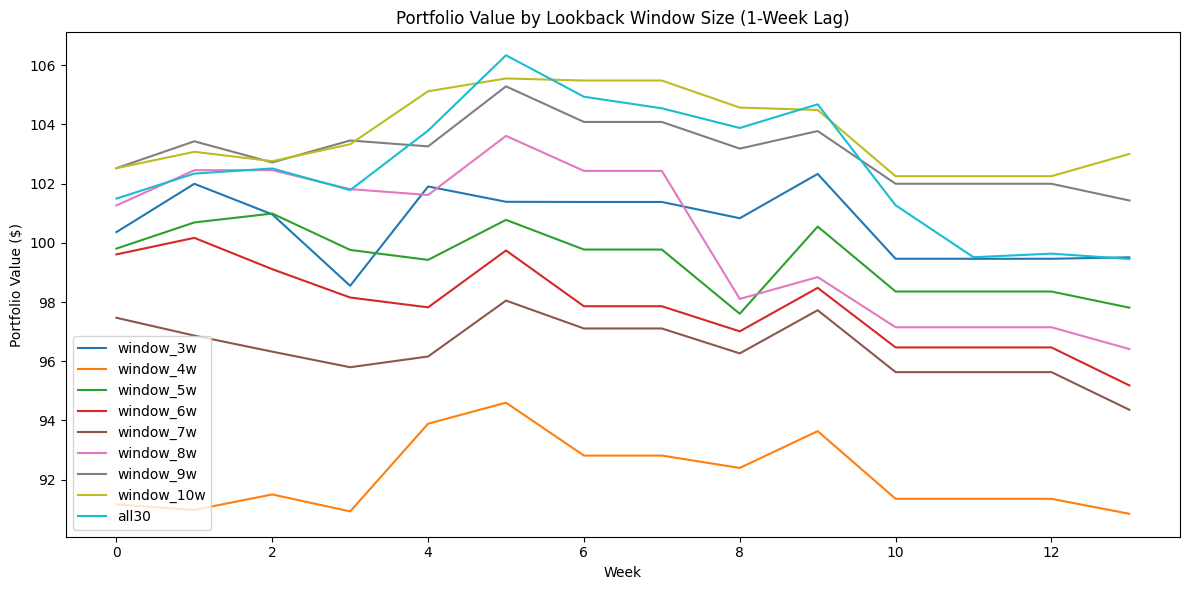

In [18]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Window size simulation, same lag (1-week), but vary the lookback window used to compute lead-lag correlations

# 1. Load data
df = pd.read_csv('/content/dow_jones_index.data')
df['date'] = pd.to_datetime(df['date'])

if df['percent_change_price'].dtype == object:
    df['percent_change_price'] = df['percent_change_price'].astype(str).str.replace('$', '').str.replace('%', '')
df['percent_change_price'] = pd.to_numeric(df['percent_change_price'], errors='coerce')

pivot_df = df.pivot(index='date', columns='stock', values='percent_change_price').sort_index()
unique_dates = pivot_df.index

# Window sizes to test (in weeks)
window_sizes = list(range(3, 11))#[4, 8, 12, 15]#, 16, 20]

START_WEEK = max(window_sizes) + 1  # Start after the largest window is available

# Initialize cash for each window strategy + baseline
cash = {f"window_{w}w": 100.00 for w in window_sizes}
cash_all30 = 100.00

history = {f"window_{w}w": [] for w in window_sizes}
history_all30 = []

weekly_edges = {f"window_{w}w": {} for w in window_sizes}
# Accumulate out-centrality scores across all weeks, per window size
cumulative_out_centrality = {f"window_{w}w": {stock: 0.0 for stock in pivot_df.columns}
                              for w in window_sizes}
centrality_counts = {f"window_{w}w": 0 for w in window_sizes}  # how many weeks contributed

print(f"Beginning Walk-Forward Window Size Simulation...\n")

# 2. run simulation week by week
for current_idx in range(len(unique_dates)):
    current_date = unique_dates[current_idx]

    # Baseline: equally weighted across all 3 stocks
    if current_idx >= START_WEEK:
        weekly_returns = pivot_df.loc[current_date].dropna()
        if len(weekly_returns) > 0:
            cash_all30 *= (1 + weekly_returns.mean() / 100.0)
        history_all30.append((current_date.strftime('%Y-%m-%d'), cash_all30))

    # window strategies: 1-week lag, varying lookback window

    for w in window_sizes:
        key = f"window_{w}w"

        # Perform calculations and update cash for this window, if enough history is available
        if current_idx >= w + 1:  # Only run if enough history exists for this specific window
            historical_data = pivot_df.iloc[current_idx - w : current_idx].copy()

            leader_matrix   = historical_data.iloc[:-1]           # Weeks t to t+w-2
            follower_matrix = historical_data.shift(-1).iloc[:-1] # Weeks t+1 to t+w-1

            # Compute cross-correlations: how well leader at t predicts follower at t+1
            lag_corr_matrix = pd.DataFrame(0.0, index=pivot_df.columns, columns=pivot_df.columns)
            for follower in pivot_df.columns:
                for leader in pivot_df.columns:
                    if leader != follower:
                        corr = leader_matrix[leader].corr(follower_matrix[follower])
                        lag_corr_matrix.at[leader, follower] = corr if pd.notna(corr) else 0.0

            # Score each stock based on triggered leaders from last week
            last_week_date = unique_dates[current_idx - 1]
            combined_scores = {}

            for stock in pivot_df.columns:
                positive_leaders = lag_corr_matrix[stock][lag_corr_matrix[stock] > 0.1]
                leader_triggered = False
                max_leader_return = 0.0

                for leader, corr_weight in positive_leaders.items():
                    leader_perf = pivot_df.at[last_week_date, leader]
                    if pd.notna(leader_perf) and leader_perf > 2.0:
                        leader_triggered = True
                        max_leader_return = max(max_leader_return, leader_perf * corr_weight)

                combined_scores[stock] = max_leader_return if leader_triggered else 0.0

            valid_scores = {k: v for k, v in combined_scores.items() if v > 0}
            top_3_stocks = sorted(valid_scores.items(), key=lambda x: x[1], reverse=True)[:3]
            all_stock_scores = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)

            # Store graph edges for this week
            edges_this_week = []
            for follower, score in top_3_stocks:
                for leader, corr in lag_corr_matrix[follower].items():
                    if corr > 0.1:
                        leader_return = pivot_df.at[last_week_date, leader]
                        if pd.notna(leader_return) and leader_return > 2.0:
                            edges_this_week.append((leader, follower, corr))
            weekly_edges[key][current_date] = edges_this_week

            # Build graph for this week and compute out-centrality
            if edges_this_week:
                G_week = nx.DiGraph()
                G_week.add_nodes_from(pivot_df.columns)  # ensure all stocks present even if no edges
                for leader, follower, corr in edges_this_week:
                    G_week.add_edge(leader, follower, weight=corr)
                out_cent = nx.out_degree_centrality(G_week)
            else:
                out_cent = {stock: 0.0 for stock in pivot_df.columns}

            for stock in pivot_df.columns:
                cumulative_out_centrality[key][stock] += out_cent[stock]
            centrality_counts[key] += 1

            # Execute trades and update cash[key]
            if top_3_stocks:
                new_cash = 0
                allocation = cash[key] / len(top_3_stocks)
                for stock, _ in top_3_stocks:
                    actual_return = pivot_df.at[current_date, stock]
                    new_cash += allocation * (1 + actual_return / 100.0) if pd.notna(actual_return) else allocation
                cash[key] = new_cash

            #New method
            # Execute trades and update cash[key] — proportional to combined score
            #if top_3_stocks: #Try to figure out how to do for all
            #    new_cash = 0
            #    total_score = sum(score for _, score in top_3_stocks)
            #    if total_score == 0:
            #        continue
            #    for stock, score in top_3_stocks:
            #        allocation = cash[key] * (score / total_score)  # weight by score
            #        actual_return = pivot_df.at[current_date, stock]
            #        new_cash += allocation * (1 + actual_return / 100.0) if pd.notna(actual_return) else allocation
            #    cash[key] = new_cash

        # Now, record history for this window strategy, but only from START_WEEK onwards.
        # This ensures all history lists (including 'all30') have the same length for plotting.
        if current_idx >= START_WEEK:
            if current_idx < w + 1:
                # If the strategy hasn't started making trades yet for this specific window 'w',
                # record its initial cash value (as no trades could have been made yet).
                history[key].append((current_date.strftime('%Y-%m-%d'), 100.00))
            else:
                # Otherwise, record its current cash value after potential trades.
                history[key].append((current_date.strftime('%Y-%m-%d'), cash[key]))

# 3. print performance table
col_headers = " | ".join([f"{'Window '+str(w)+'w':<15}" for w in window_sizes])
print(f"{'Week':<6} | {'Date':<12} | {col_headers} | {'All 30':<15}")
print("-" * (6 + 3 + 12 + 3 + 17 * len(window_sizes) + 18))

all_perf = {dt.strftime('%Y-%m-%d'): {'week': i+1, 'all30': 100.0,
            **{f"window_{w}w": 100.0 for w in window_sizes}}
            for i, dt in enumerate(unique_dates)}

for key in [f"window_{w}w" for w in window_sizes]:
    for dt, val in history[key]:
        all_perf[dt][key] = val

for dt, val in history_all30:
    all_perf[dt]['all30'] = val

for dt in sorted(all_perf.keys()):
    row = all_perf[dt]
    if row['week'] >= START_WEEK:
        vals = " | ".join([f"${row[f'window_{w}w']:<14.2f}" for w in window_sizes])
        print(f" unconverted_output=Week {row['week']:<6} | {dt:<12} | {vals} | ${row['all30']:<14.2f}")

# 4. PLOT PORTFOLIO VALUES OVER TIME
money_df = pd.DataFrame({
    **{f"window_{w}w": [v for _, v in history[f"window_{w}w"]] for w in window_sizes},
    "all30": [v for _, v in history_all30]
})
cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in np.linspace(0, 1, len(window_sizes) + 1)]
money_df.plot(kind="line", figsize=(12, 6), title="Portfolio Value by Lookback Window Size (1-Week Lag)", color = colors)
plt.xlabel("Week")
plt.ylabel("Portfolio Value ($)")
plt.tight_layout()
plt.show()

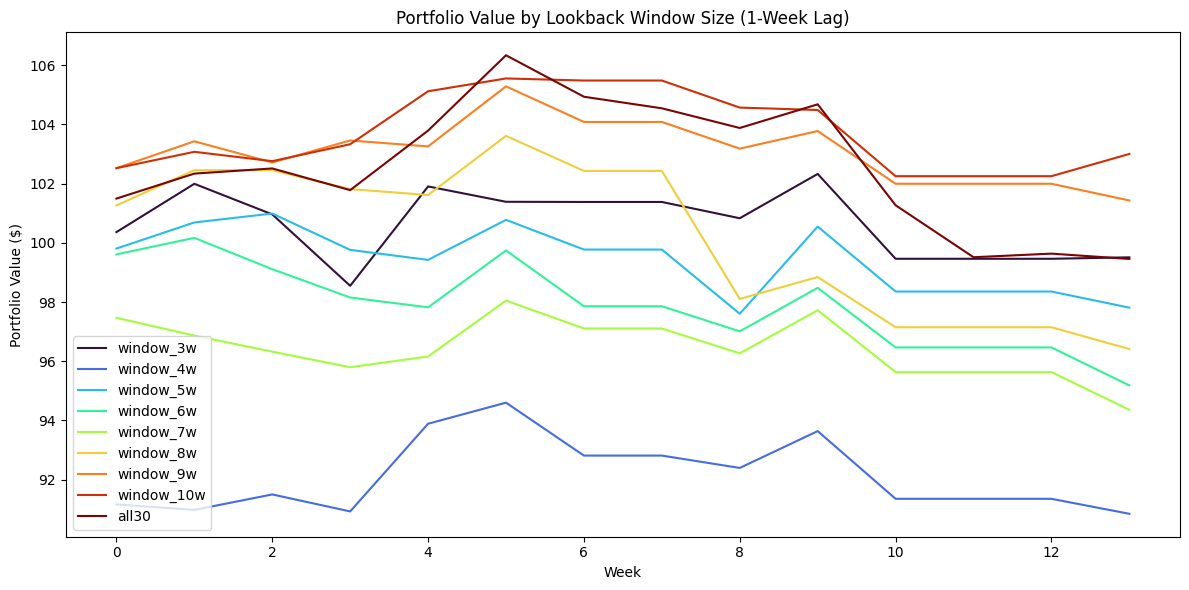

In [19]:
##For better plotting
from matplotlib.colors import ListedColormap
base_cmap = plt.colormaps['turbo']
unique_cmap = base_cmap.resampled(len(money_df.columns)) # Resample to the number of columns to get enough distinct colors
colors = [unique_cmap(i) for i in np.linspace(0, 1, len(money_df.columns))]
money_df.plot(kind="line", figsize=(12, 6), title="Portfolio Value by Lookback Window Size (1-Week Lag)", color = colors)
plt.xlabel("Week")
plt.ylabel("Portfolio Value ($)")
plt.tight_layout()
plt.show()

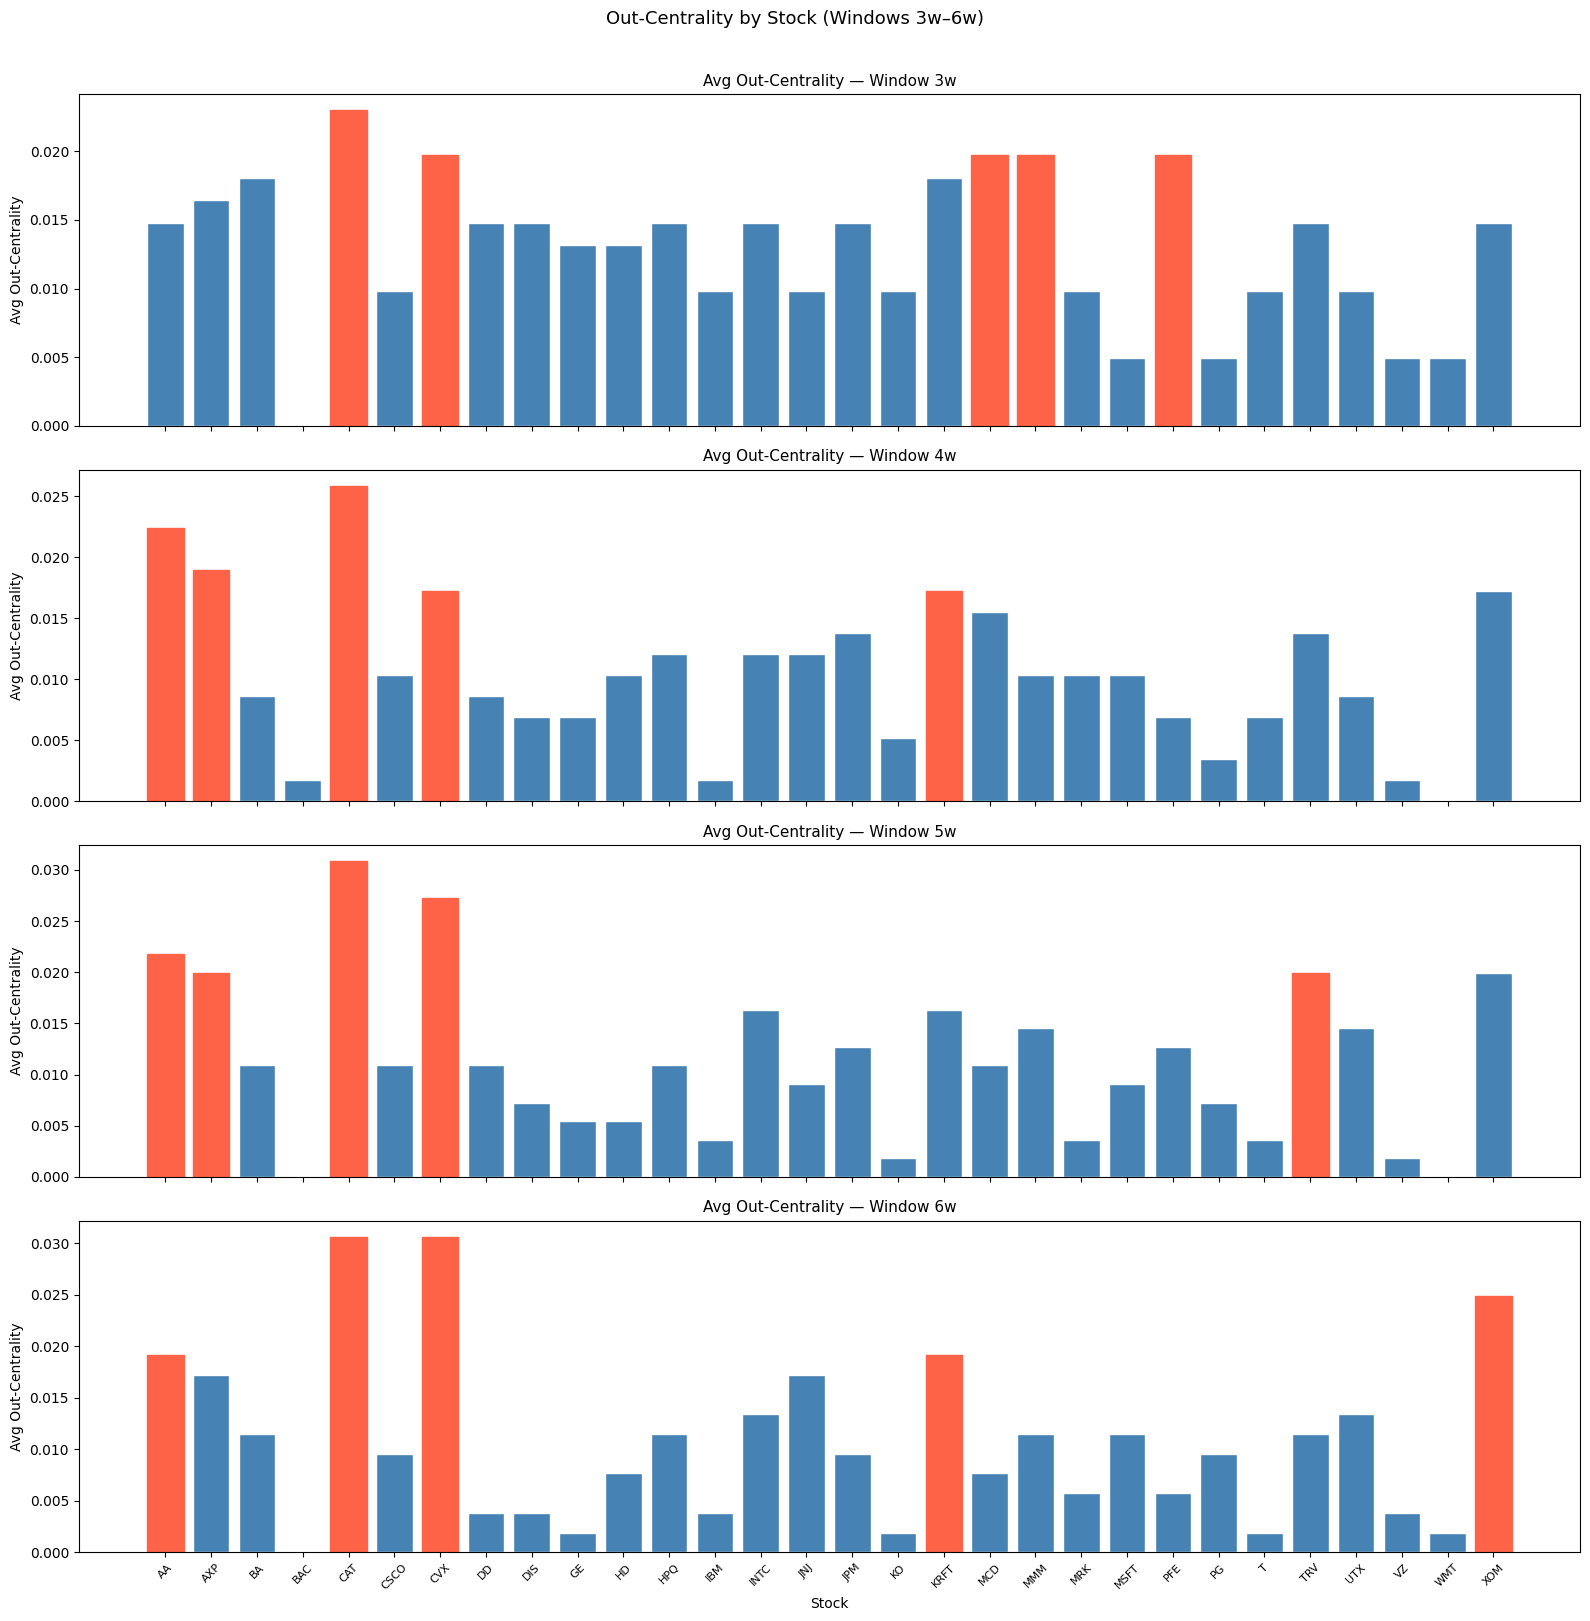

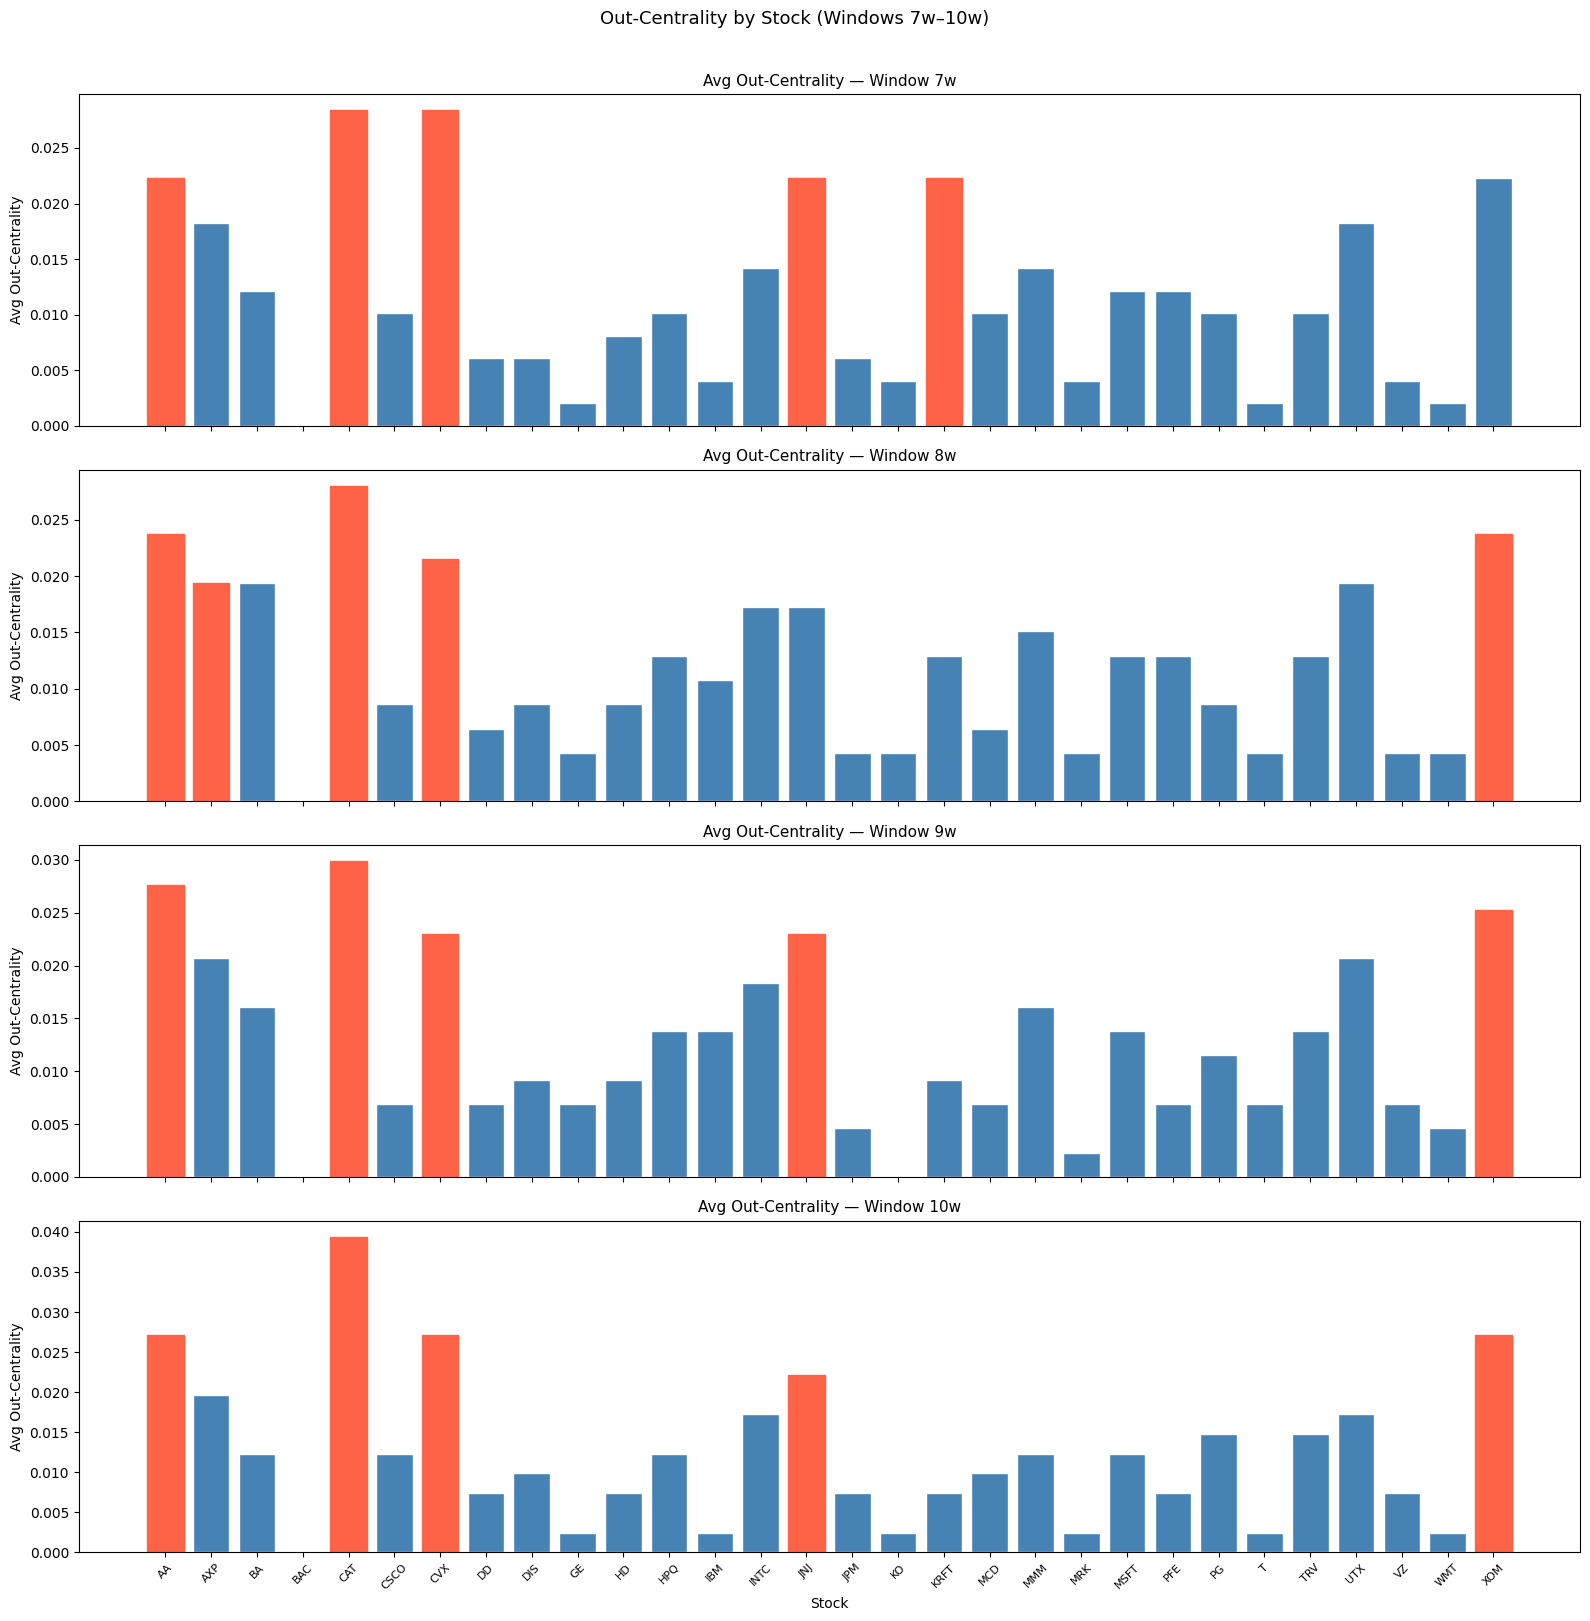

In [20]:
#Centrality Plotting
# 5. PLOT AVERAGE OUT-CENTRALITY PER WINDOW SIZE
stocks_sorted = sorted(pivot_df.columns)
n_stocks = len(stocks_sorted)
plots_per_fig = 4  # window sizes per figure
window_keys = [f"window_{w}w" for w in window_sizes]

for fig_start in range(0, len(window_sizes), plots_per_fig):
    fig_windows = window_sizes[fig_start : fig_start + plots_per_fig]
    n_plots = len(fig_windows)
    fig, axes = plt.subplots(n_plots, 1, figsize=(16, 4 * n_plots), sharex=True)
    if n_plots == 1:
        axes = [axes]

    for ax, w in zip(axes, fig_windows):
        key = f"window_{w}w"
        count = centrality_counts[key] if centrality_counts[key] > 0 else 1
        avg_centrality = [cumulative_out_centrality[key][s] / count for s in stocks_sorted]

        bars = ax.bar(stocks_sorted, avg_centrality, color='steelblue', edgecolor='white')
        ax.set_title(f"Avg Out-Centrality — Window {w}w", fontsize=11)
        ax.set_ylabel("Avg Out-Centrality")
        ax.tick_params(axis='x', rotation=45, labelsize=8)

        # Annotate top 5 bars
        top5_idx = sorted(range(n_stocks), key=lambda i: avg_centrality[i], reverse=True)[:5]
        for i in top5_idx:
            bars[i].set_color('tomato')

    axes[-1].set_xlabel("Stock")
    fig.suptitle(f"Out-Centrality by Stock (Windows {fig_windows[0]}w–{fig_windows[-1]}w)",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

Interestingly, both the 9 and 10 week windows have the exact same top 5 leaders based on outward centrality, and these are the only two that turn a profit.

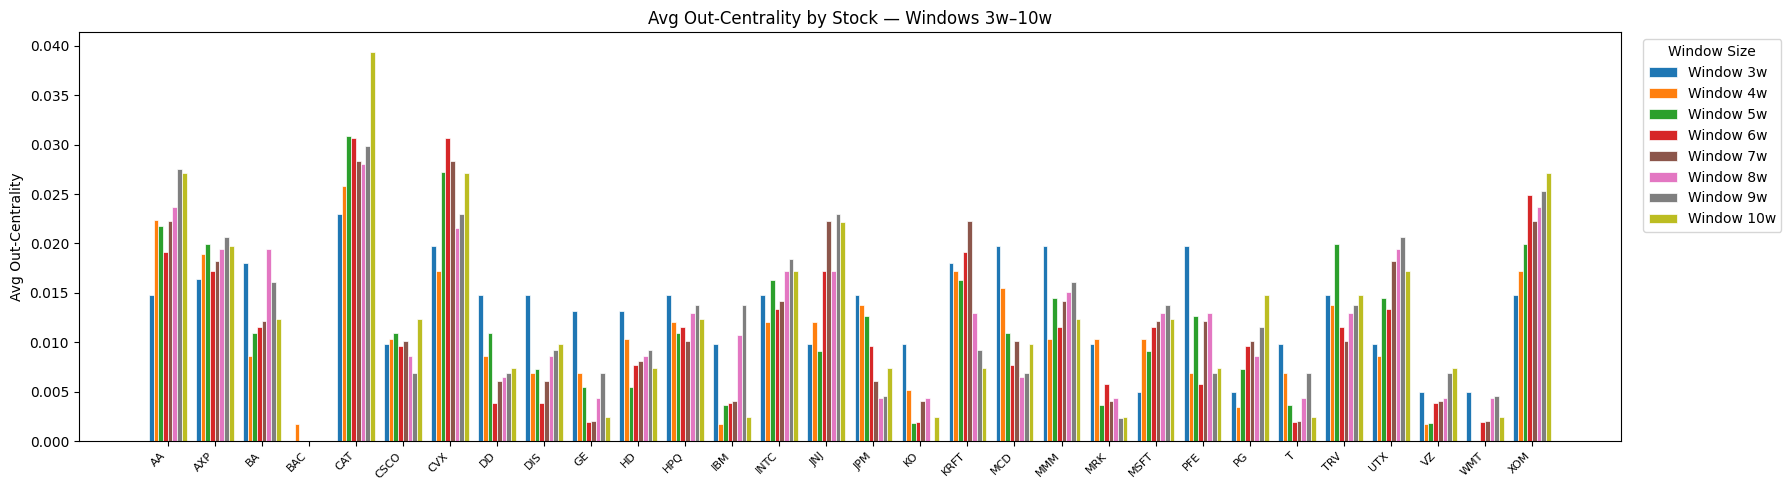

In [21]:
# 5. PLOT AVERAGE OUT-CENTRALITY — GROUPED BY STOCK, COLORED BY WINDOW SIZE
stocks_sorted = sorted(pivot_df.columns)
n_stocks = len(stocks_sorted)
plots_per_fig = 8  # number of window sizes per figure #CHANGE TO 4 OR 5
x = np.arange(n_stocks)

for fig_start in range(0, len(window_sizes), plots_per_fig):
    fig_windows = window_sizes[fig_start : fig_start + plots_per_fig]
    n_bars = len(fig_windows)
    bar_width = 0.8 / n_bars  # total bar group width = 0.8

    fig, ax = plt.subplots(figsize=(18, 5))
    cmap = plt.get_cmap('tab10')

    for i, w in enumerate(fig_windows):
        key = f"window_{w}w"
        count = centrality_counts[key] if centrality_counts[key] > 0 else 1
        avg_centrality = [cumulative_out_centrality[key][s] / count for s in stocks_sorted]
        offsets = x + (i - n_bars / 2 + 0.5) * bar_width

        ax.bar(offsets, avg_centrality, width=bar_width, label=f"Window {w}w",
               color=cmap(i / plots_per_fig), edgecolor='white', linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(stocks_sorted, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel("Avg Out-Centrality")
    ax.set_title(f"Avg Out-Centrality by Stock — Windows {fig_windows[0]}w–{fig_windows[-1]}w")
    ax.legend(title="Window Size", bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

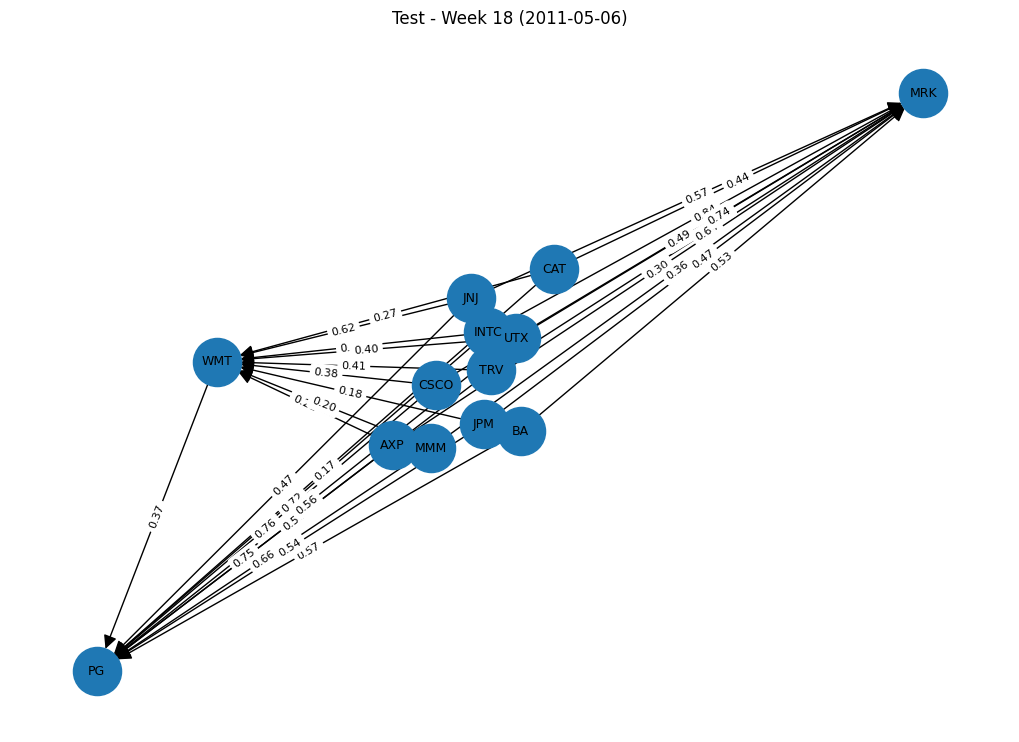

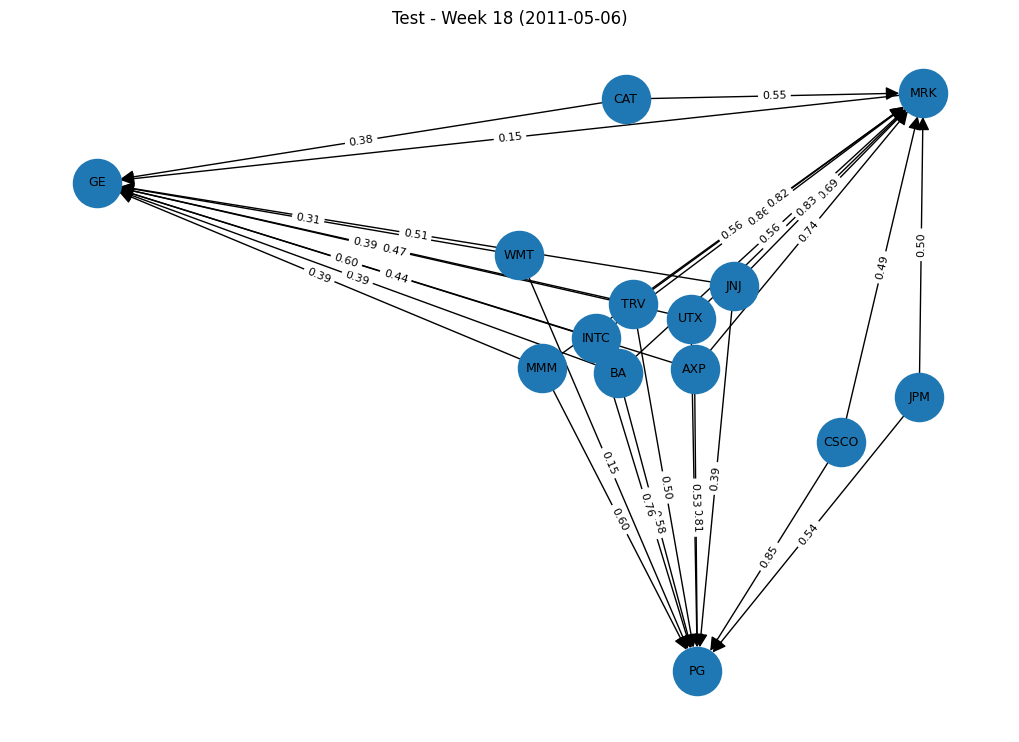

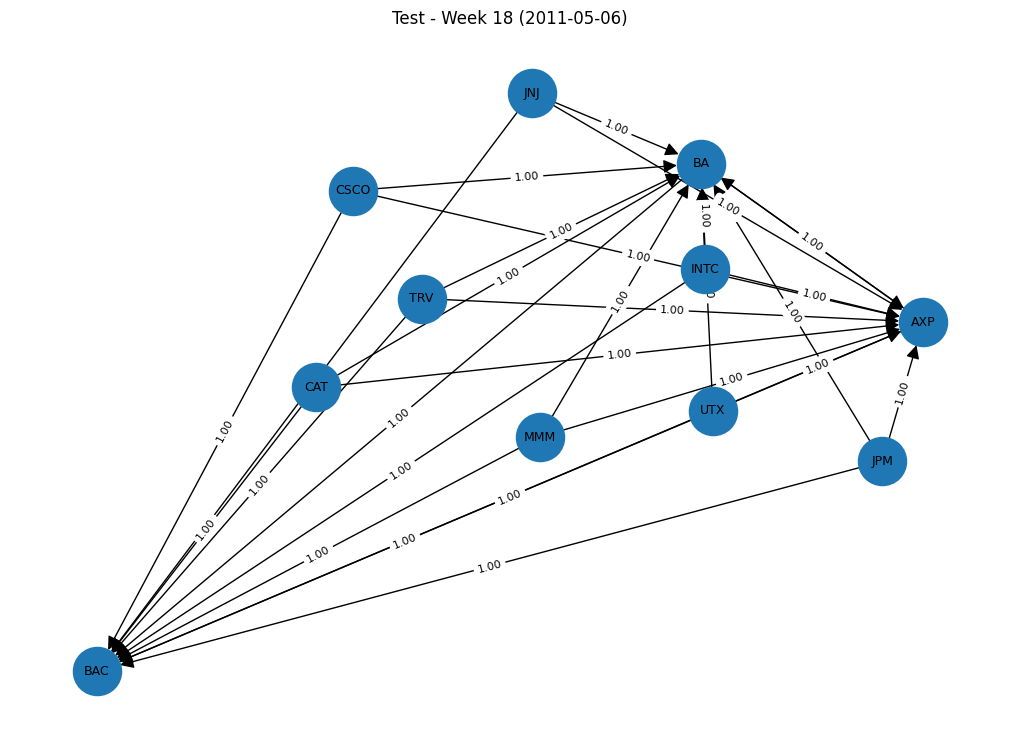

In [22]:
#Plotting the networks
def plot_weekly_graphs(weekly_edges, title_prefix, weeks = 'All'):
    for current_date, edges in weekly_edges.items():
        week_num = list(unique_dates).index(current_date) + 1

        if week_num < START_WEEK:
            continue

        if weeks != 'All' and week_num not in weeks:
            continue

        if not edges:
            continue

        G = nx.DiGraph()

        for leader, follower, corr in edges:
            G.add_edge(leader, follower, weight=corr)

        plt.figure(figsize=(10, 7))
        pos = nx.spring_layout(G, seed=42)

        nx.draw(
            G,
            pos,
            with_labels=True,
            node_size=1200,
            font_size=9,
            arrows=True,
            arrowsize=20
        )

        edge_labels = {
            (u, v): f"{d['weight']:.2f}"
            for u, v, d in G.edges(data=True)
        }

        nx.draw_networkx_edge_labels(
            G,
            pos,
            edge_labels=edge_labels,
            font_size=8
        )

        plt.title(f"{title_prefix} - Week {week_num} ({current_date.strftime('%Y-%m-%d')})")
        plt.show()

week_list = [18]
plot_weekly_graphs(weekly_edges['window_10w'], "Test", weeks = week_list)
plot_weekly_graphs(weekly_edges['window_9w'], "Test", weeks = week_list)
plot_weekly_graphs(weekly_edges['window_3w'], "Test", weeks = week_list)

In [23]:
money_df

,window_3w,window_4w,window_5w,window_6w,window_7w,window_8w,window_9w,window_10w,all30
0,100.363401,91.164481,99.807086,99.610507,97.469195,101.264060,102.522890,102.522890,101.495959
1,101.994919,90.979981,100.688985,100.169116,96.867835,102.454048,103.430707,103.075903,102.339729
2,100.962012,91.501660,100.990431,99.110989,96.325193,102.456343,102.715660,102.759415,102.514031
3,98.549322,90.928404,99.762013,98.153619,95.799311,101.814457,103.458433,103.332083,101.781415
4,101.905607,93.890649,99.424871,97.821913,96.161564,101.617782,103.258582,105.120439,103.792226
5,101.387362,94.601729,100.776854,99.743034,98.050077,103.613450,105.286474,105.553762,106.337073
6,101.381383,92.814544,99.773952,97.858721,97.108095,102.430682,104.084608,105.483337,104.936131
7,101.381383,92.814544,99.773952,97.858721,97.108095,102.430682,104.084608,105.483337,104.545203
8,100.831633,92.397125,97.604750,97.011191,96.267065,98.105748,103.183157,104.569772,103.880555
9,102.328666,93.641098,100.550715,98.480005,97.724613,98.844763,103.776786,104.488004,104.680173


10 week window seems to be optimal, it and the 9 week were the only ones to turn a profit. Those two, along with the 3 week window, are the only ones to outperform the baseline method of investing in all 30 every week.

# Including Negative Leaders

Beginning Walk-Forward Window Size Simulation (with Negative Leaders)...

Week   | Date         | Window 3w       | Window 4w       | Window 5w       | Window 6w       | Window 7w       | Window 8w       | Window 9w       | Window 10w      | All 30         
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Week 11     | 2011-03-18   | $100.00         | $100.00         | $100.00         | $100.00         | $100.00         | $100.00         | $100.00         | $100.00         | $100.00        
Week 12     | 2011-03-25   | $103.33         | $91.22          | $97.15          | $94.02          | $97.01          | $98.71          | $99.77          | $102.52         | $101.50        
Week 13     | 2011-04-01   | $105.64         | $92.10          | $96.63          | $94.49          | $97.19          | $98.73          | $99.79          | $102.20         | $102.34     

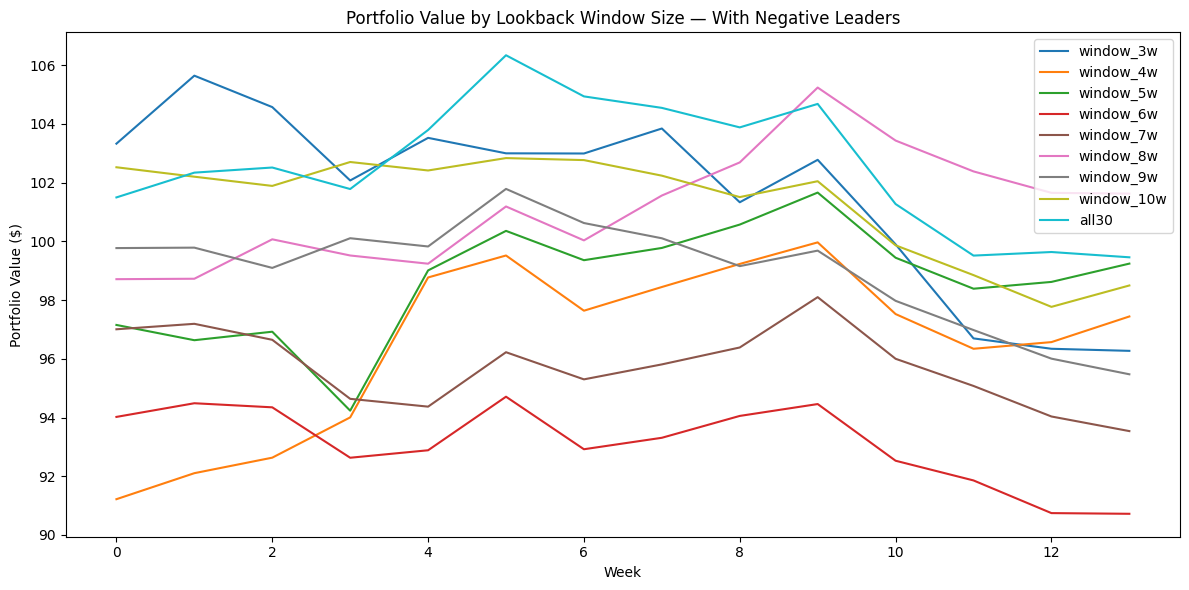

In [25]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# window size simulation with negative leaders, Same lag (1-week), varying lookback window
# Negative correlation: leader decrease → follower increase


# 1. load and prepare data
df = pd.read_csv('/content/dow_jones_index.data')
df['date'] = pd.to_datetime(df['date'])

if df['percent_change_price'].dtype == object:
    df['percent_change_price'] = df['percent_change_price'].astype(str).str.replace('$', '').str.replace('%', '')
df['percent_change_price'] = pd.to_numeric(df['percent_change_price'], errors='coerce')

pivot_df = df.pivot(index='date', columns='stock', values='percent_change_price').sort_index()
unique_dates = pivot_df.index

# Window sizes to test (in weeks)
window_sizes = list(range(3, 11))

START_WEEK = max(window_sizes) + 1

cash = {f"window_{w}w": 100.00 for w in window_sizes}
cash_all30 = 100.00

history = {f"window_{w}w": [] for w in window_sizes}
history_all30 = []

weekly_edges = {f"window_{w}w": {} for w in window_sizes}

print(f"Beginning Walk-Forward Window Size Simulation (with Negative Leaders)...\n")

# 2. RUN SIMULATION WEEK-BY-WEEK
for current_idx in range(len(unique_dates)):
    current_date = unique_dates[current_idx]

    # baseline, equally weighted across all three stocks
    if current_idx >= START_WEEK:
        weekly_returns = pivot_df.loc[current_date].dropna()
        if len(weekly_returns) > 0:
            cash_all30 *= (1 + weekly_returns.mean() / 100.0)
        history_all30.append((current_date.strftime('%Y-%m-%d'), cash_all30))

    # window strategies: 1-week lag, varying lookback window
    for w in window_sizes:
        key = f"window_{w}w"

        if current_idx >= w + 1:
            historical_data = pivot_df.iloc[current_idx - w : current_idx].copy()

            leader_matrix   = historical_data.iloc[:-1]
            follower_matrix = historical_data.shift(-1).iloc[:-1]

            lag_corr_matrix = pd.DataFrame(0.0, index=pivot_df.columns, columns=pivot_df.columns)
            for follower in pivot_df.columns:
                for leader in pivot_df.columns:
                    if leader != follower:
                        corr = leader_matrix[leader].corr(follower_matrix[follower])
                        lag_corr_matrix.at[leader, follower] = corr if pd.notna(corr) else 0.0

            last_week_date = unique_dates[current_idx - 1]
            combined_scores = {}

            for stock in pivot_df.columns:
                all_leaders = lag_corr_matrix[stock]

                # --- Positive leaders (same as before) ---
                # High positive corr + leader went UP last week → buy follower
                positive_leaders = all_leaders[all_leaders > 0.1]
                pos_triggered = False
                max_pos_score = 0.0
                for leader, corr_weight in positive_leaders.items():
                    leader_perf = pivot_df.at[last_week_date, leader]
                    if pd.notna(leader_perf) and leader_perf > 2.0:
                        pos_triggered = True
                        max_pos_score = max(max_pos_score, leader_perf * corr_weight)

                # --- Negative leaders (new) ---
                # High negative corr + leader went DOWN last week → buy follower
                negative_leaders = all_leaders[all_leaders < -0.1]
                neg_triggered = False
                max_neg_score = 0.0
                for leader, corr_weight in negative_leaders.items():
                    leader_perf = pivot_df.at[last_week_date, leader]
                    if pd.notna(leader_perf) and leader_perf < -2.0:  # leader decreased
                        neg_triggered = True
                        # Use abs of both so score is positive and comparable
                        max_neg_score = max(max_neg_score, abs(leader_perf) * abs(corr_weight))

                # Take the best signal across both types
                if pos_triggered or neg_triggered:
                    combined_scores[stock] = max(max_pos_score, max_neg_score)
                else:
                    combined_scores[stock] = 0.0

            valid_scores = {k: v for k, v in combined_scores.items() if v > 0}
            top_3_stocks = sorted(valid_scores.items(), key=lambda x: x[1], reverse=True)[:3]

            # Store graph edges — track which leader type triggered each edge
            edges_this_week = []
            for follower, score in top_3_stocks:
                for leader, corr in lag_corr_matrix[follower].items():
                    leader_return = pivot_df.at[last_week_date, leader]
                    if pd.notna(leader_return):
                        if corr > 0.1 and leader_return > 2.0:
                            edges_this_week.append((leader, follower, corr))
                        elif corr < -0.1 and leader_return < -2.0:
                            edges_this_week.append((leader, follower, corr))
            weekly_edges[key][current_date] = edges_this_week

            # Execute trades
            if top_3_stocks:
                new_cash = 0
                allocation = cash[key] / len(top_3_stocks)
                for stock, _ in top_3_stocks:
                    actual_return = pivot_df.at[current_date, stock]
                    new_cash += allocation * (1 + actual_return / 100.0) if pd.notna(actual_return) else allocation
                cash[key] = new_cash

        if current_idx >= START_WEEK:
            if current_idx < w + 1:
                history[key].append((current_date.strftime('%Y-%m-%d'), 100.00))
            else:
                history[key].append((current_date.strftime('%Y-%m-%d'), cash[key]))

# 3. print performance table
col_headers = " | ".join([f"{'Window '+str(w)+'w':<15}" for w in window_sizes])
print(f"{'Week':<6} | {'Date':<12} | {col_headers} | {'All 30':<15}")
print("-" * (6 + 3 + 12 + 3 + 17 * len(window_sizes) + 18))

all_perf = {dt.strftime('%Y-%m-%d'): {'week': i+1, 'all30': 100.0,
            **{f"window_{w}w": 100.0 for w in window_sizes}}
            for i, dt in enumerate(unique_dates)}

for key in [f"window_{w}w" for w in window_sizes]:
    for dt, val in history[key]:
        all_perf[dt][key] = val

for dt, val in history_all30:
    all_perf[dt]['all30'] = val

for dt in sorted(all_perf.keys()):
    row = all_perf[dt]
    if row['week'] >= START_WEEK:
        vals = " | ".join([f"${row[f'window_{w}w']:<14.2f}" for w in window_sizes])
        print(f"Week {row['week']:<6} | {dt:<12} | {vals} | ${row['all30']:<14.2f}")

# 4. PLOT PORTFOLIO VALUES OVER TIME
money_df = pd.DataFrame({
    **{f"window_{w}w": [v for _, v in history[f"window_{w}w"]] for w in window_sizes},
    "all30": [v for _, v in history_all30]
})
cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in np.linspace(0, 1, len(window_sizes) + 1)]
money_df.plot(kind="line", figsize=(12, 6), title="Portfolio Value by Lookback Window Size — With Negative Leaders", color=colors)
plt.xlabel("Week")
plt.ylabel("Portfolio Value ($)")
plt.tight_layout()
plt.show()

In [26]:
money_df

,window_3w,window_4w,window_5w,window_6w,window_7w,window_8w,window_9w,window_10w,all30
0,103.326359,91.218640,97.152754,94.020840,97.005288,98.711375,99.770373,102.522890,101.495959
1,105.641851,92.104590,96.632978,94.486292,97.191148,98.726143,99.785299,102.201461,102.339729
2,104.572010,92.632717,96.922281,94.347366,96.646695,100.069023,99.095453,101.887657,102.514031
3,102.073053,94.004423,94.233100,92.630381,94.636526,99.518105,100.106300,102.701836,101.781415
4,103.524011,98.769789,99.010059,92.884809,94.370566,99.238426,99.824968,102.413210,103.792226
5,102.997535,99.517821,100.356402,94.708971,96.223907,101.187366,101.785428,102.835374,106.337073
6,102.991462,97.637763,99.357683,92.919760,95.299468,100.032293,100.623527,102.766762,104.936131
7,103.842633,98.444689,99.774752,93.309804,95.809058,101.560076,100.104342,102.236518,104.545203
8,101.330738,99.230369,100.571048,94.054504,96.385234,102.687909,99.155857,101.506953,103.880555
9,102.776222,99.964723,101.660390,94.458605,98.099393,105.237304,99.683941,102.047559,104.680173


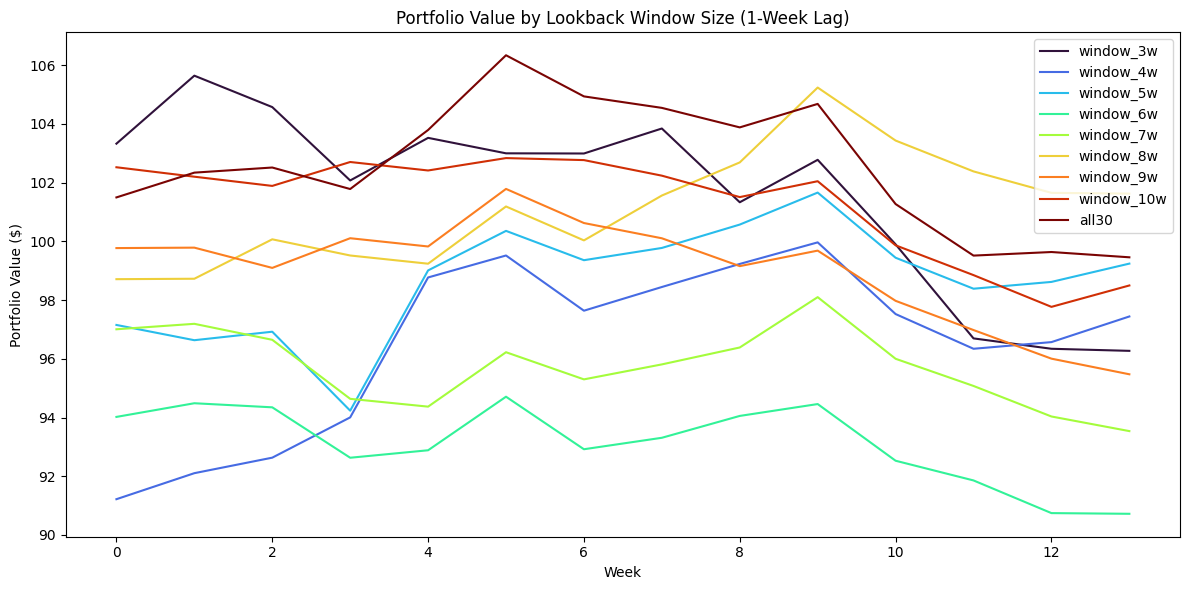

In [ ]:
#And the new plotting stuff
#For better plotting
from matplotlib.colors import ListedColormap
base_cmap = plt.colormaps['turbo']
unique_cmap = base_cmap.resampled(len(money_df.columns)) # Resample to the number of columns to get enough distinct colors
colors = [unique_cmap(i) for i in np.linspace(0, 1, len(money_df.columns))]
money_df.plot(kind="line", figsize=(12, 6), title="Portfolio Value by Lookback Window Size (1-Week Lag)", color = colors)
plt.xlabel("Week")
plt.ylabel("Portfolio Value ($)")
plt.tight_layout()
plt.show()

When including negative leaders, the 8 week window seems to work best, and is the only one to turn a profit by the end, notably, a decent amount lower than the profit from the 10 week with only positive leaders.